# **Prediction & Out sample forward testing on `x_test()` data:**

# **Importing Libraries and Data**

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
import random
import tensorflow as tf
import numba
from keras.layers import Dense, Dropout
from keras.models import Sequential
from keras.regularizers import l1,l2
from keras.optimizers import Adam
from sklearn.model_selection import train_test_split

In [3]:
symbol="BTC-USD"
df=pd.DataFrame(data=yf.download(tickers=symbol,period="3y",interval="1d",auto_adjust=True)["Close"])
df["LR"]=np.log(df[symbol]/df[symbol].shift(1))
features=["Direction","SMA",'BB','rolling_min','rolling_max','momentum','Volatility']
sma_s=5;sma_l=30;sma_window=12
df[f"{features[0]}"]=np.where(df["LR"]>0,1,0)
df[f"{features[1]}"]=df[symbol].rolling(window=sma_s).mean()-df[symbol].rolling(window=sma_l).mean()
df[f"{features[2]}"]=(df[symbol]-df[symbol].rolling(window=sma_window).mean())/df[symbol].rolling(window=sma_window).std()
df[f"{features[3]}"]=df[symbol].rolling(window=sma_window).min()/(df[symbol]-1)
df[f"{features[4]}"]=df[symbol].rolling(window=sma_window).max()/(df[symbol]-1)
df[f"{features[5]}"]=df["LR"].rolling(window=sma_window).mean()
df[f"{features[6]}"]=df["LR"].rolling(window=sma_window).std()
df.dropna(inplace=True)
lags=5;cols=[]
for i in features:
  for j in range(1,lags+1):
    col=f"{i}_lag_{j}"
    df[col]=df[i].shift(periods=j)
    cols.append(col)
df.dropna(inplace=True);df

[*********************100%***********************]  1 of 1 completed


Ticker,BTC-USD,LR,Direction,SMA,BB,rolling_min,rolling_max,momentum,Volatility,Direction_lag_1,...,momentum_lag_1,momentum_lag_2,momentum_lag_3,momentum_lag_4,momentum_lag_5,Volatility_lag_1,Volatility_lag_2,Volatility_lag_3,Volatility_lag_4,Volatility_lag_5
Date,,,,,,,,,,,,,,,,,,,,,
2023-03-30,28033.562500,-0.011170,0,2752.022591,0.584436,0.968156,1.011268,0.003236,0.026791,1.0,...,0.002763,0.007061,0.008951,0.010278,0.010645,0.027116,0.035992,0.036450,0.035129,0.035240
2023-03-31,28478.484375,0.015746,1,2687.788997,1.403340,0.953030,1.000035,0.001297,0.024728,0.0,...,0.003236,0.002763,0.007061,0.008951,0.010278,0.026791,0.027116,0.035992,0.036450,0.035129
2023-04-01,28411.035156,-0.002371,0,2777.499349,1.078047,0.955292,1.002409,0.001910,0.024521,1.0,...,0.001297,0.003236,0.002763,0.007061,0.008951,0.024728,0.026791,0.027116,0.035992,0.036450
2023-04-02,28199.308594,-0.007480,0,2769.180599,0.647948,0.962465,1.009936,0.000069,0.024309,0.0,...,0.001910,0.001297,0.003236,0.002763,0.007061,0.024521,0.024728,0.026791,0.027116,0.035992
2023-04-03,27790.220703,-0.014613,0,2476.307422,-0.267125,0.976634,1.024803,0.001460,0.022780,0.0,...,0.000069,0.001910,0.001297,0.003236,0.002763,0.024309,0.024521,0.024728,0.026791,0.027116
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-02-20,68005.421875,0.015529,1,-7884.985807,-0.077952,0.973787,1.031121,-0.002724,0.018988,1.0,...,-0.002844,-0.005027,0.006137,-0.004908,-0.007906,0.018866,0.019015,0.039884,0.060660,0.061238
2026-02-21,68003.765625,-0.000024,0,-7337.574349,0.066629,0.973811,1.025953,-0.002555,0.019004,1.0,...,-0.002724,-0.002844,-0.005027,0.006137,-0.004908,0.018988,0.018866,0.019015,0.039884,0.060660
2026-02-22,67659.390625,-0.005077,0,-6576.390495,-0.161370,0.978768,1.031175,-0.001386,0.018312,0.0,...,-0.002555,-0.002724,-0.002844,-0.005027,0.006137,0.019004,0.018988,0.018866,0.019015,0.039884


**Splitting Train and Test Data:**

In [4]:
split_point=int(0.75*len(df))
x_train=df.iloc[:split_point].copy()
x_test=df.iloc[split_point:].copy()
# train_test=[x_train,x_test]
print(f"Training data: {x_train.index[0]} to {x_train.index[-1]}")
print(f"Testing data: {x_test.index[0]} to {x_test.index[-1]}")
mu,std=x_train.mean(),x_train.std()
x_train_stand=(x_train-mu)/std    # standardizing training data
# mu_test,std_test=x_test.mean(),x_test.std()
x_test_stand=(x_test-mu)/std    # standardizing testing data
x_train

Training data: 2023-03-30 00:00:00 to 2025-06-03 00:00:00
Testing data: 2025-06-04 00:00:00 to 2026-02-24 00:00:00


Ticker,BTC-USD,LR,Direction,SMA,BB,rolling_min,rolling_max,momentum,Volatility,Direction_lag_1,...,momentum_lag_1,momentum_lag_2,momentum_lag_3,momentum_lag_4,momentum_lag_5,Volatility_lag_1,Volatility_lag_2,Volatility_lag_3,Volatility_lag_4,Volatility_lag_5
Date,,,,,,,,,,,,,,,,,,,,,
2023-03-30,28033.562500,-0.011170,0,2752.022591,0.584436,0.968156,1.011268,0.003236,0.026791,1.0,...,0.002763,0.007061,0.008951,0.010278,0.010645,0.027116,0.035992,0.036450,0.035129,0.035240
2023-03-31,28478.484375,0.015746,1,2687.788997,1.403340,0.953030,1.000035,0.001297,0.024728,0.0,...,0.003236,0.002763,0.007061,0.008951,0.010278,0.026791,0.027116,0.035992,0.036450,0.035129
2023-04-01,28411.035156,-0.002371,0,2777.499349,1.078047,0.955292,1.002409,0.001910,0.024521,1.0,...,0.001297,0.003236,0.002763,0.007061,0.008951,0.024728,0.026791,0.027116,0.035992,0.036450
2023-04-02,28199.308594,-0.007480,0,2769.180599,0.647948,0.962465,1.009936,0.000069,0.024309,0.0,...,0.001910,0.001297,0.003236,0.002763,0.007061,0.024521,0.024728,0.026791,0.027116,0.035992
2023-04-03,27790.220703,-0.014613,0,2476.307422,-0.267125,0.976634,1.024803,0.001460,0.022780,0.0,...,0.000069,0.001910,0.001297,0.003236,0.002763,0.024309,0.024521,0.024728,0.026791,0.027116
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-05-30,103998.570312,-0.015677,0,3564.137240,-1.799827,1.000010,1.073807,-0.001938,0.018450,0.0,...,0.001956,0.003403,0.004114,0.004619,0.003804,0.020141,0.018992,0.018558,0.018397,0.018656
2025-05-31,104638.093750,0.006131,1,2332.157292,-1.389497,0.993898,1.067244,-0.000767,0.018482,0.0,...,-0.001938,0.001956,0.003403,0.004114,0.004619,0.018450,0.020141,0.018992,0.018558,0.018397
2025-06-01,105652.101562,0.009644,1,1372.248438,-0.865273,0.984359,1.057001,-0.000894,0.018398,1.0,...,-0.000767,-0.001938,0.001956,0.003403,0.004114,0.018482,0.018450,0.020141,0.018992,0.018558


**Creating & Fittig DNN Model:**

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5605 - loss: 0.6863  
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step


/tmp/ipython-input-2036908992.py:34: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.hist(pred,bins=50);plt.legend(fontsize=12)


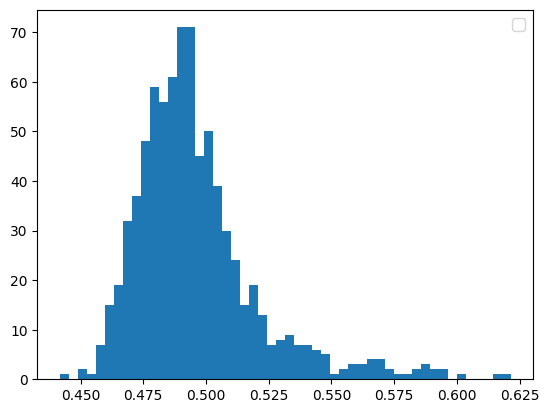

In [9]:
def set_seeds(seed=100):
  random.seed(seed);np.random.seed(seed)
  tf.random.set_seed(seed)

def class_weight(df):
  c0,c1=np.bincount(df['Direction'])
  w0=(1/c0)*(len(df))/2
  w1=(1/c1)*(len(df))/2
  return {0:w0,1:w1}
optimizer=Adam(learning_rate=0.0001)
def create_model(hl=2,hu=100,dropout=False,rate=0.3,regularize=False,reg=l1(0.0005),optimizer=optimizer,input_dim=None):
  if not regularize:
    reg=None
  model=Sequential()
  model.add(Dense(hu,input_shape=(input_dim,),activity_regularizer=reg,activation="relu"))
  if dropout:
    model.add(Dropout(rate,seed=100))
  for layer in range(hl):
    model.add(Dense(hu,activation="relu",activity_regularizer=reg))
    if dropout:
      model.add(Dropout(rate,seed=100))
  model.add(Dense(1,activation="sigmoid"))
  model.compile(loss="binary_crossentropy",optimizer=optimizer,metrics=["accuracy"])
  return model

  # Fitting DNN Model:
  set_seeds(seed=100)
model=create_model(hl=3,hu=50,dropout=True,input_dim=len(cols))
model.fit(x=x_train_stand[cols],y=x_train['Direction'],epochs=50,verbose=False,class_weight=class_weight(x_train))
model.evaluate(x_train_stand[cols],x_train['Direction'])
pred=model.predict(x_train_stand[cols])

# Plotting histogram
plt.hist(pred,bins=50);plt.legend(fontsize=12)
plt.show()

In [ ]:
x_train["Probability"]=model.predict(x_train_stand[cols])
x_train["Position"]=np.where(x_train["Probability"]>0.53,1,np.nan)
x_train["Position"]=np.where(x_train["Probability"]<0.47,-1,x_train["Position"])
x_train["Position"]=x_train["Position"].ffill()
x_train["Position"].value_counts()
x_train["Strategy"]=x_train["Position"]*x_train['LR']
x_train["C_Return"]=np.exp(x_train["LR"].cumsum())
x_train["C_Strategy"]=np.exp(x_train["Strategy"].cumsum())
x_train[["C_Return","C_Strategy"]].plot(figsize=(12,8),fontsize=12)
plt.legend(fontsize=12)
plt.show()

# **Predicting Prices on `x_test` data:**

In [ ]:
model.evaluate(x_test_stand[cols],x_test['Direction'])
pred_test=numba.jit(model.predict(x_test_stand[cols]))
plt.hist(pred_test,bins=50)
plt.show()

**Adding the data column of predicted price probability into `x_test`**

In [ ]:
x_test["Probability"]=model.predict(x_test_stand[cols])
x_test["Position"]=np.where(x_test['Probability']<0.47,-1,np.nan)
x_test["Position"]=np.where(x_test['Probability']>0.53,1,x_test["Position"])
# x_test["Position"]=np.where(x_test['Probability']<=0.53 and x_test["Probability"]>=0.47 ,0,x_test["Position"])
x_test["Position"]=x_test["Position"].ffill()   # hold the previous position
x_test["Position"].value_counts()

In [ ]:
x_test["Strategy"]=x_test["Position"]*x_test['LR']
x_test["C_Return"]=np.exp(x_test["LR"].cumsum())
x_test["C_Strategy"]=np.exp(x_test["Strategy"].cumsum())
x_test[["C_Return","C_Strategy"]].plot(figsize=(12,8),fontsize=12)
plt.legend(fontsize=12)
plt.show()